## import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import warnings
warnings.filterwarnings("ignore")

## Data Collection and Analysis

In [2]:
## loading the data from csv file to a pandas Dataframe
insurance_dataset = pd.read_csv('insurance dataset.csv')
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
insurance_dataset.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [4]:
insurance_dataset.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
insurance_dataset.shape

(1338, 7)

In [7]:
insurance_dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
null_values = 100 * (insurance_dataset.isnull().sum()/insurance_dataset.shape[0])
null_values

age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64

In [10]:
null_values[null_values>45].sort_values(ascending=False)

Series([], dtype: float64)

In [11]:
cols = null_values[null_values>45].sort_values(ascending=False).index
insurance_dataset.drop(labels=cols,axis=1,inplace=True)
insurance_dataset.shape

(1338, 7)

In [12]:
null_values = 100 * (insurance_dataset.isnull().sum()/insurance_dataset.shape[0]) 
null_values[(null_values <13) & (null_values>0)]

Series([], dtype: float64)

In [13]:
## categorical features: Sex,Smoker,Region

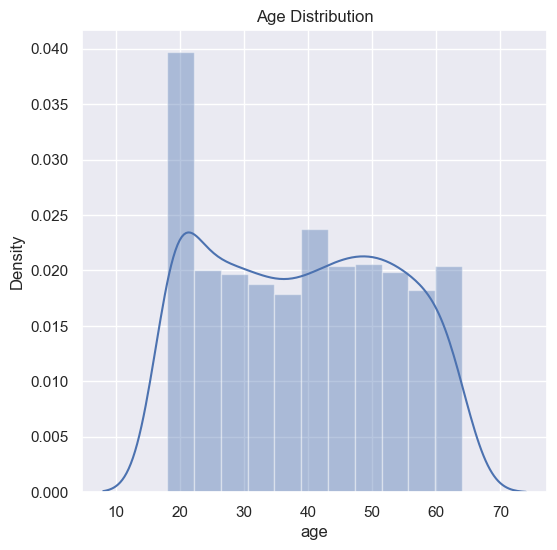

In [14]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['age'])
plt.title('Age Distribution')
plt.show()

Text(0.5, 1.0, 'sex Distribution')

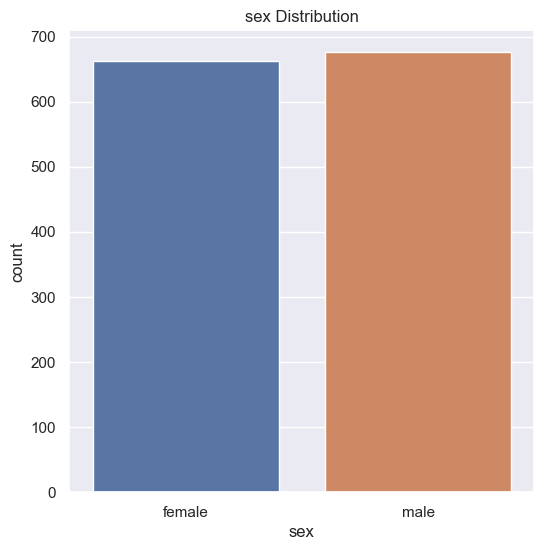

In [15]:
# Gender column
plt.figure(figsize=(6,6))
sns.countplot(x = 'sex',data = insurance_dataset)
plt.title('sex Distribution')

In [16]:
insurance_dataset['sex'].value_counts()

male      676
female    662
Name: sex, dtype: int64

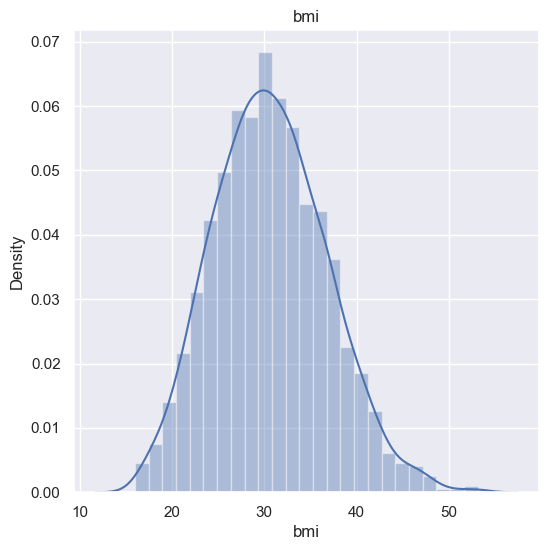

In [17]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['bmi'])
plt.title('bmi')
plt.show()

In [18]:
insurance_dataset.replace({'sex':{'male':0,'female':1}},inplace = True)
insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace = True)
insurance_dataset.replace({'region':{'northwest':1,'northeast':2, 'southwest':3,'southeast':4}},inplace = True)

In [19]:
X = insurance_dataset.drop(columns='charges',axis=1)
y = insurance_dataset['charges']

In [20]:
print(X)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       3
1      18    0  33.770         1       1       4
2      28    0  33.000         3       1       4
3      33    0  22.705         0       1       1
4      32    0  28.880         0       1       1
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       1
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       4
1336   21    1  25.800         0       1       3
1337   61    1  29.070         0       0       1

[1338 rows x 6 columns]


In [21]:
print(y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


<AxesSubplot:xlabel='smoker', ylabel='Density'>

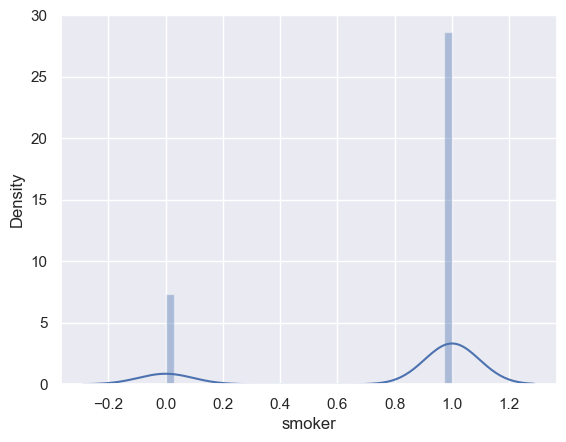

In [22]:
sns.distplot(insurance_dataset.smoker)

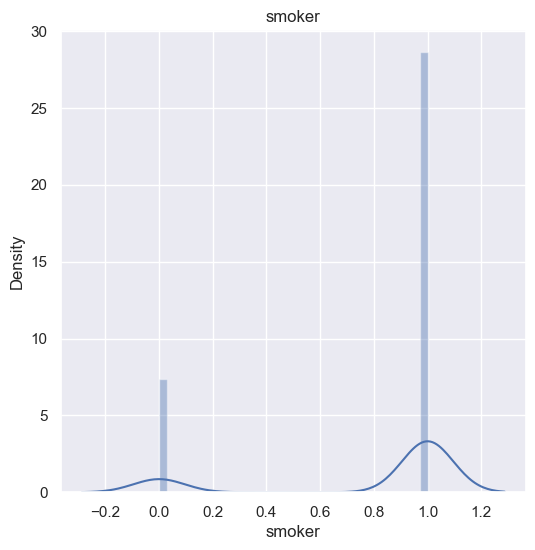

In [23]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['smoker'])
plt.title('smoker')
plt.show()

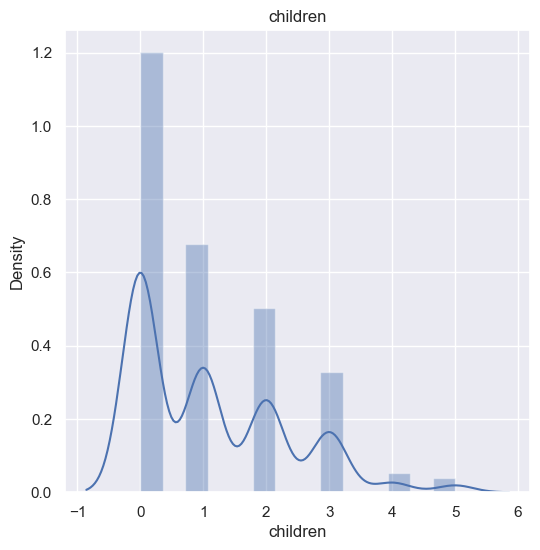

In [24]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['children'])
plt.title('children')
plt.show()

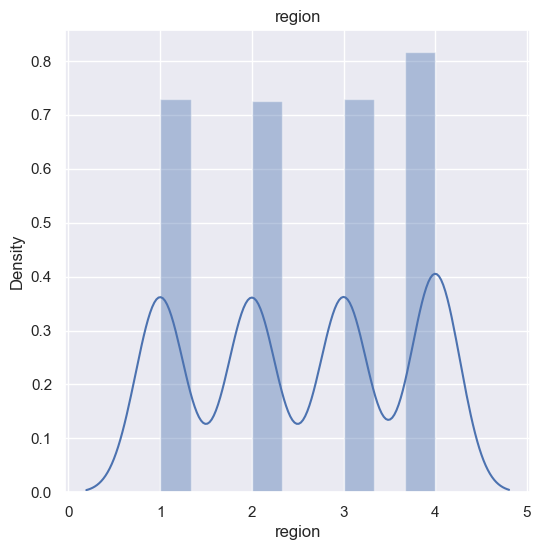

In [25]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['region'])
plt.title('region')
plt.show()

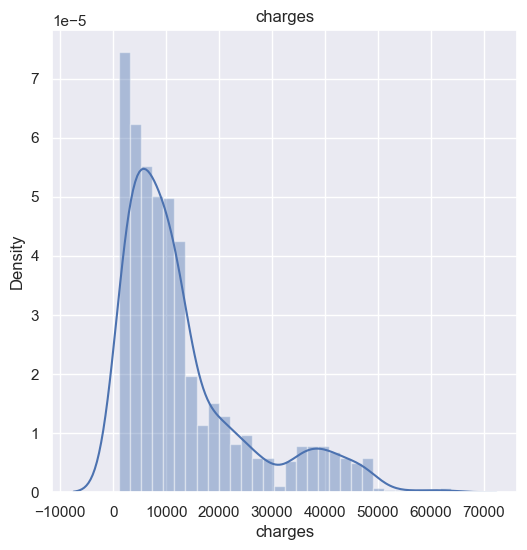

In [26]:
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['charges'])
plt.title('charges')
plt.show()

In [27]:
charges = insurance_dataset["charges"].value_counts(normalize=True)

In [28]:
insurance_dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

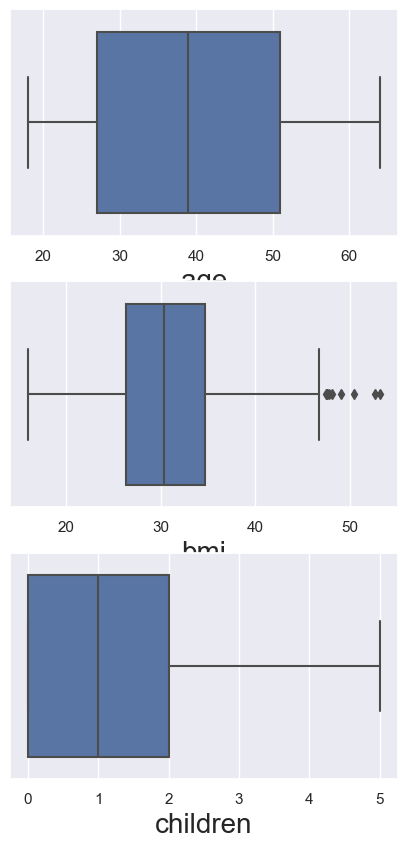

In [29]:
box=insurance_dataset[['age', 'bmi','children']]
plt.figure(figsize=(5,10), facecolor='white')
plotnumber = 1

for column in box:
    if plotnumber<=6 :     # as there are 9 columns in the data
        ax = plt.subplot(3,1,plotnumber)
        sns.boxplot(x=box[column])
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

In [30]:
## Analysis of continous variables
def findoutliers(column):
    outliers=[]
    Q1=column.quantile(.25)
    Q3=column.quantile(.75)
    IQR=Q3-Q1
    lower_limit=Q1-(1.5*IQR)
    upper_limit=Q3+(1.5*IQR)
    for out1 in column:
        if out1>upper_limit or out1 <lower_limit:
            outliers.append(out1)
            
    return np.array(outliers)

<AxesSubplot:xlabel='bmi'>

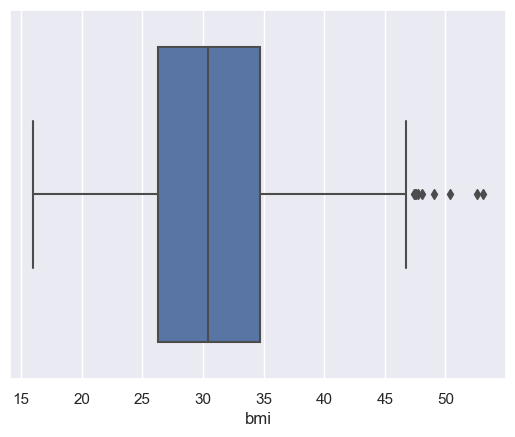

In [31]:
sns.boxplot(insurance_dataset.bmi)

In [32]:
from scipy import stats
for column in box:
    print(stats.skew(box[column]),column)

0.055610083072599126 age
0.28372857291709386 bmi
0.9373281163874423 children


In [33]:
for column in box:
    print(stats.kurtosis(box[column]),column)

-1.2449206804584227 age
-0.05502310583700032 bmi
0.1972174268623732 children


In [34]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,3,16884.92400
1,18,0,33.770,1,1,4,1725.55230
2,28,0,33.000,3,1,4,4449.46200
3,33,0,22.705,0,1,1,21984.47061
4,32,0,28.880,0,1,1,3866.85520


In [35]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler() ## object creation
insurance_dataset[['age', 'sex','bmi']]= sc.fit_transform(insurance_dataset[['age', 'sex','bmi']])

In [36]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,-1.438764,1.010519,-0.453320,0,0,3,16884.92400
1,-1.509965,-0.989591,0.509621,1,1,4,1725.55230
2,-0.797954,-0.989591,0.383307,3,1,4,4449.46200
3,-0.441948,-0.989591,-1.305531,0,1,1,21984.47061
4,-0.513149,-0.989591,-0.292556,0,1,1,3866.85520


In [37]:
insurance_dataset.corr()

,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.020856,0.109272,0.042469,0.025019,-0.005212,0.299008
sex,0.020856,1.000000,-0.046371,-0.017163,0.076185,-0.016121,-0.057292
bmi,0.109272,-0.046371,1.000000,0.012759,-0.003750,0.261829,0.198341
children,0.042469,-0.017163,0.012759,1.000000,-0.007673,-0.019257,0.067998
smoker,0.025019,0.076185,-0.003750,-0.007673,1.000000,-0.053930,-0.787251
region,-0.005212,-0.016121,0.261829,-0.019257,-0.053930,1.000000,0.056993
charges,0.299008,-0.057292,0.198341,0.067998,-0.787251,0.056993,1.000000


<AxesSubplot:>

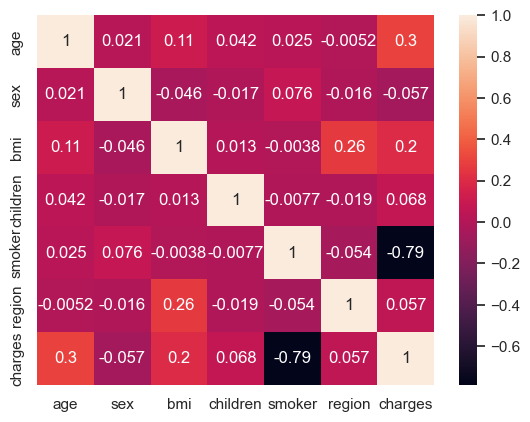

In [38]:
sns.heatmap(insurance_dataset.corr(),annot=True)

<AxesSubplot:>

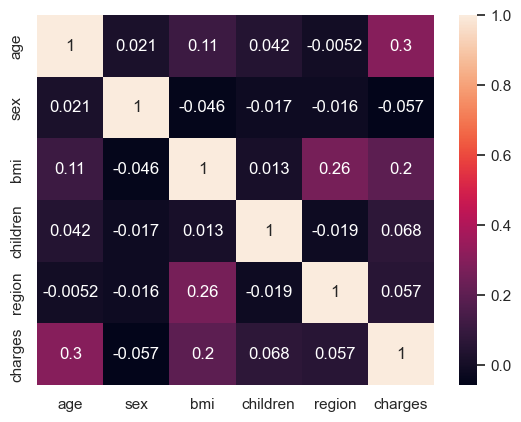

In [39]:
sns.heatmap(insurance_dataset.drop('smoker',axis=1).corr(),annot=True)

In [40]:
X=insurance_dataset.iloc[:,0:-1]
y=insurance_dataset.charges

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [43]:
from sklearn.linear_model import LinearRegression
LR=LinearRegression()
LR.fit(X_train,y_train)
y_hat=LR.predict(X_test)

In [44]:
y_train_predict=LR.predict(X_train)
from sklearn.metrics import r2_score
train_score=r2_score(y_train,y_train_predict)
train_score

0.7445275825163911

In [45]:
lr = LinearRegression()
lr.fit(X_train,y_train)
svm = SVR()
svm.fit(X_train,y_train)
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
gr = GradientBoostingRegressor()
gr.fit(X_train,y_train)

GradientBoostingRegressor()

In [46]:
y_pred1 = lr.predict(X_test)
y_pred2 = svm.predict(X_test)
y_pred3 = rf.predict(X_test)
y_pred4 = gr.predict(X_test)



df1 = pd.DataFrame({'Actual':y_test,'LR':y_pred1,'svm':y_pred2,'rf':y_pred3,'gr':y_pred4})

In [47]:
df1

,Actual,LR,svm,rf,gr
764,9095.06825,8569.027921,9437.071321,10426.627536,10439.228445
887,5272.17580,7226.242261,9417.213949,5398.134939,5606.916108
890,29330.98315,37082.125966,9492.950021,28268.059099,28566.928173
1293,9301.89355,9704.404710,9440.574065,12008.725036,9902.029326
259,33750.29180,27154.894451,9403.306521,34516.069995,34032.647133
...,...,...,...,...,...
342,13217.09450,12407.173239,9482.058145,12908.002340,15095.379369
308,11944.59435,14400.524856,9484.637128,12210.065148,13087.304572
1128,14358.36437,7695.376058,9405.368238,5217.074133,5348.881694
503,32548.34050,25958.982415,9399.437172,33825.497241,35494.122600


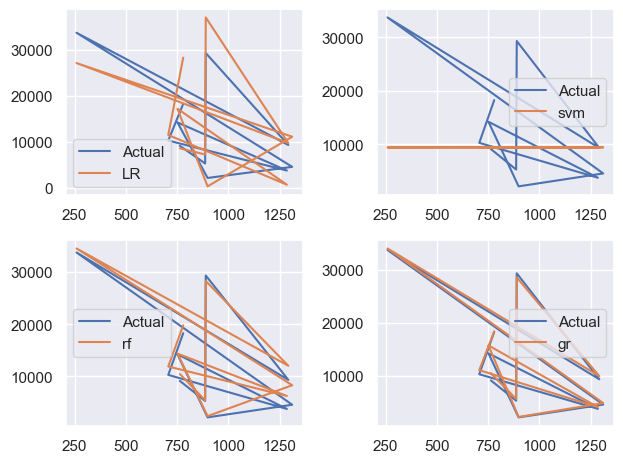

In [48]:
plt.subplot(221)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['LR'].iloc[0:11],label="LR")
plt.legend()


plt.subplot(222)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['svm'].iloc[0:11],label="svm")
plt.legend()

plt.subplot(223)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['rf'].iloc[0:11],label="rf")
plt.legend()


plt.subplot(224)
plt.plot(df1['Actual'].iloc[0:11],label='Actual')
plt.plot(df1['gr'].iloc[0:11],label="gr")

plt.tight_layout()


plt.legend()


In [49]:
from sklearn import metrics

In [50]:
score1=metrics.r2_score(y_test,y_pred1)
score2=metrics.r2_score(y_test,y_pred2)
score3=metrics.r2_score(y_test,y_pred3)
score4=metrics.r2_score(y_test,y_pred4)

In [51]:
print(score1,score2,score3,score4)

0.7667469908213234 -0.09548003110575842 0.8509953382461486 0.8623623097145213


In [52]:
s1 = metrics.mean_absolute_error(y_test,y_pred1)
s2 = metrics.mean_absolute_error(y_test,y_pred2)
s3 = metrics.mean_absolute_error(y_test,y_pred3)
s4 = metrics.mean_absolute_error(y_test,y_pred4)

In [53]:
print(s1,s2,s3,s4)

4245.940270673539 8487.96113724879 2609.6138757475373 2491.428032536737


In [54]:
data = {'age':40,
        'sex':1,
        'bmi':40.30,
        'children':4,
        'smoker':1,
        'region':2}

df = pd.DataFrame(df1,index=[0])
df

,Actual,LR,svm,rf,gr
0,NaN,NaN,NaN,NaN,NaN


In [56]:
model = LinearRegression()

In [57]:
model.fit(X_train,y_train)

LinearRegression()

In [58]:
y_predict = model.predict(X_test)
y_predict

array([ 8569.02792102,  7226.24226101, 37082.12596551,  9704.40470976,
       27154.89445082, 11099.50396214,   287.75903995, 17192.26142479,
         649.86159841, 11475.04981963, 28330.08174632,  9614.31257617,
        5059.10380215, 38318.60361415, 40188.64744507, 37002.33742225,
       15084.32748246, 35750.87578953,  8949.03881572, 31635.73858748,
        4066.74697862, 10388.4371046 ,  2569.89417776,  6682.25980692,
       11495.6971861 , 12580.08990064, 14740.82601338,  6299.0628445 ,
        9568.01685349,  2011.8942882 ,  9304.15869233, 13280.99111107,
        4337.56975838,  3555.02545142,  4676.84319149, 12693.94100914,
        2120.14150719,  9005.52894884, 33467.65638726, 32462.62589045,
        4048.14515865,  4516.4774556 , 14365.65205159, 11701.01027073,
        8645.58566659, 12392.84601145,  5405.29550866,  3302.36665877,
       35390.2179744 ,  9016.67395506, 15712.31509893,  2178.67516687,
       12532.23586296,  1080.70337419, 13313.1736781 , 12249.76589852,
      

In [59]:
test_score=r2_score(y_test,y_hat)
test_score

0.7667469908213234

In [60]:
X_train.shape,X_test.shape

((1003, 6), (335, 6))

In [61]:
import seaborn as sb

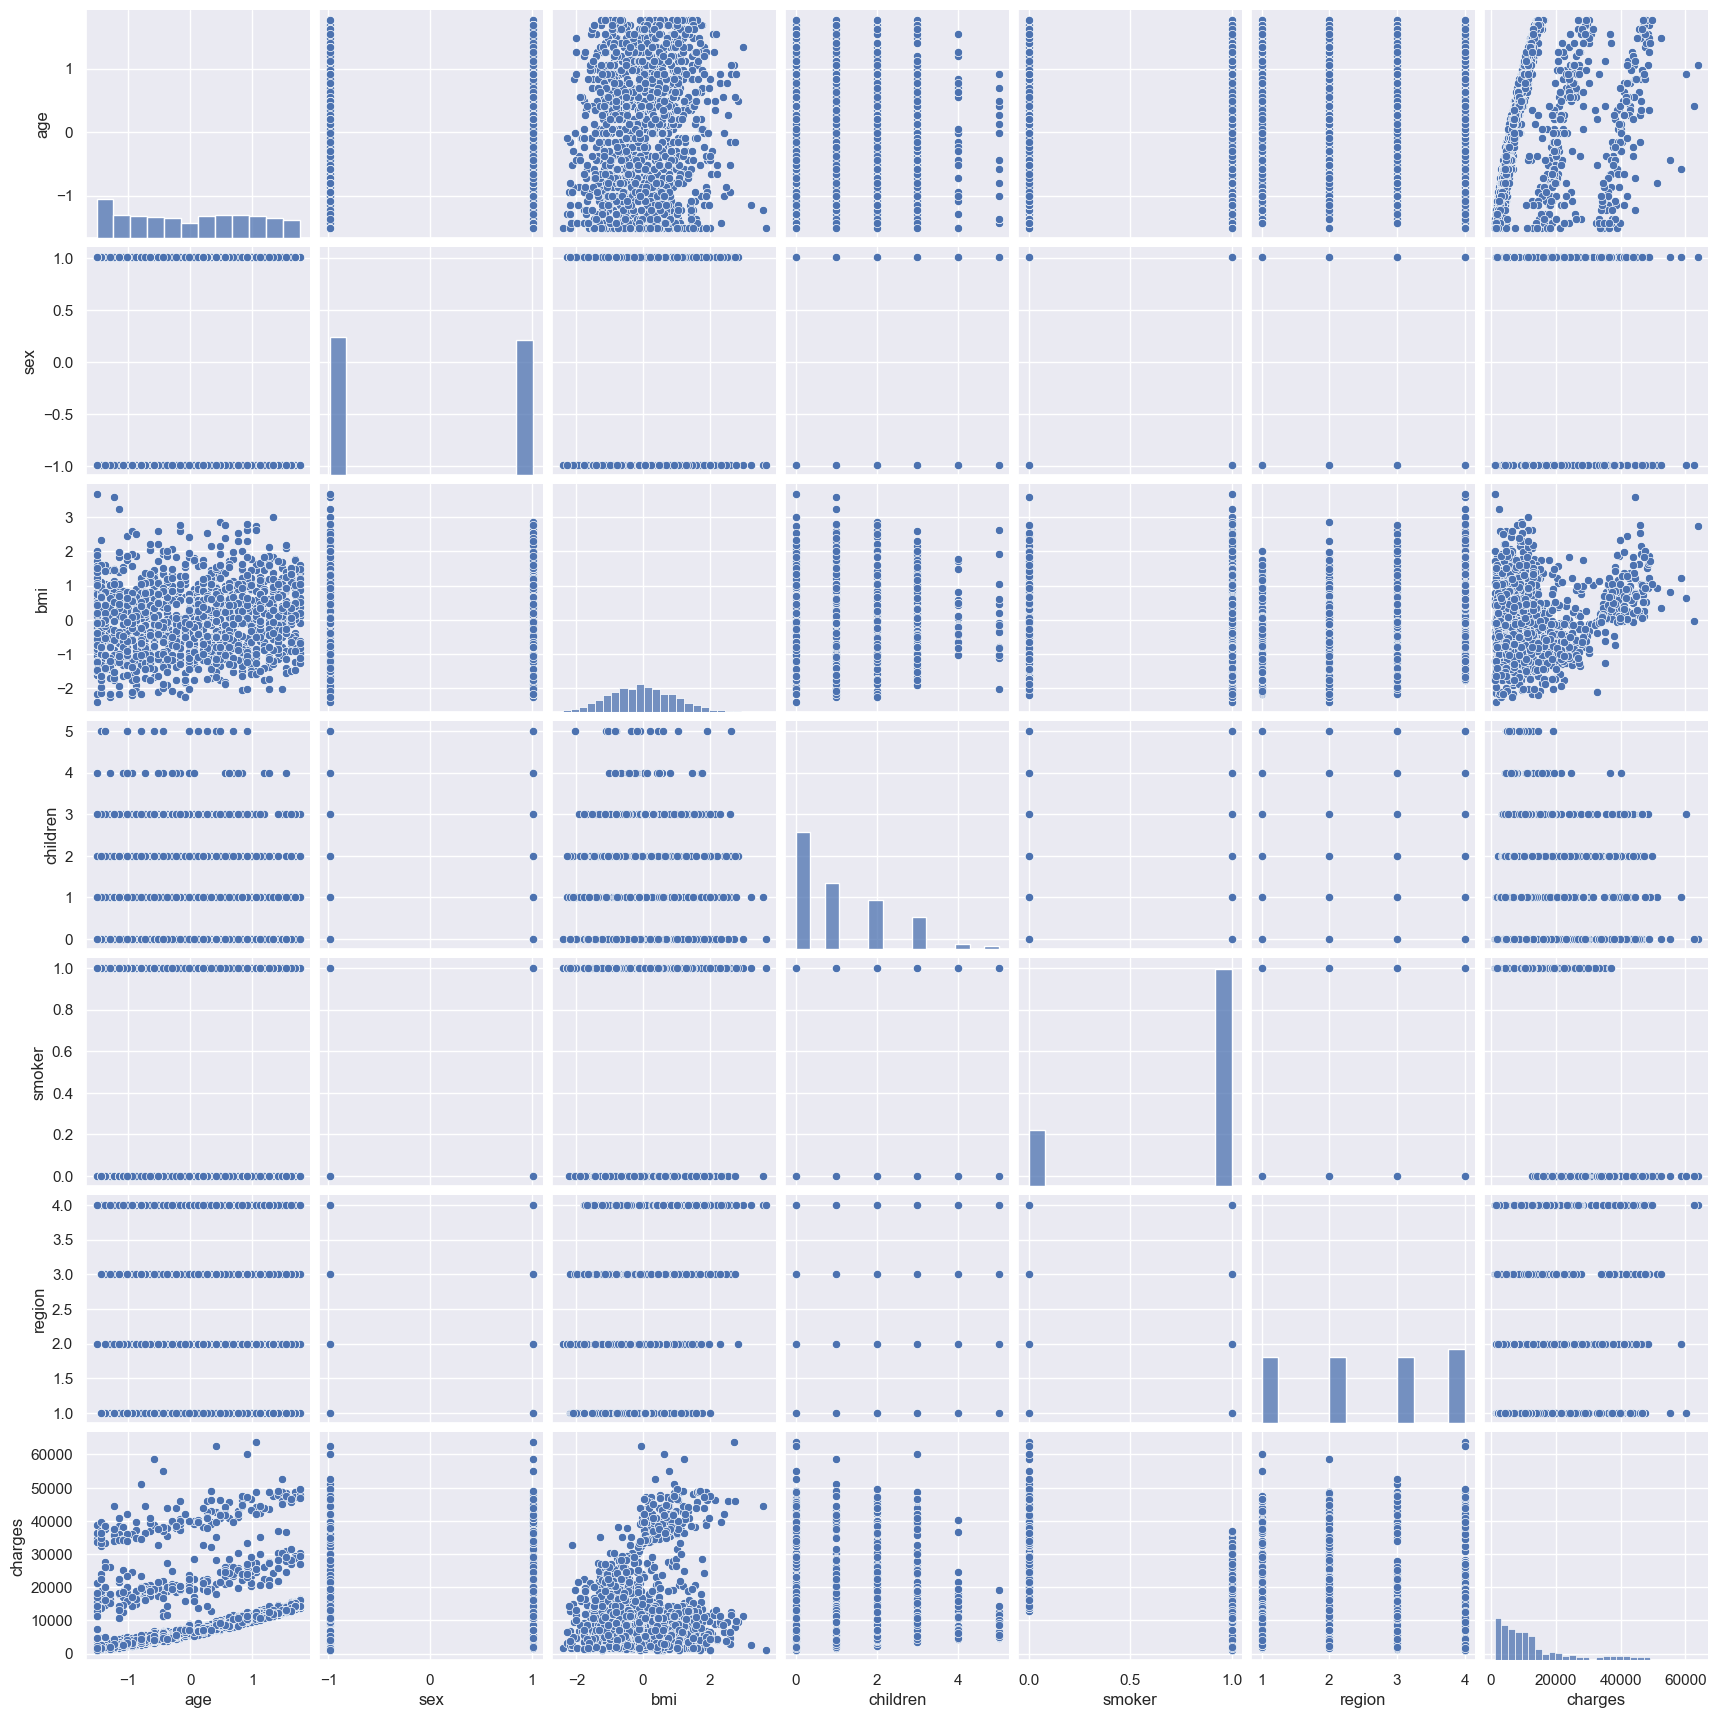

In [62]:
sb.pairplot(insurance_dataset)

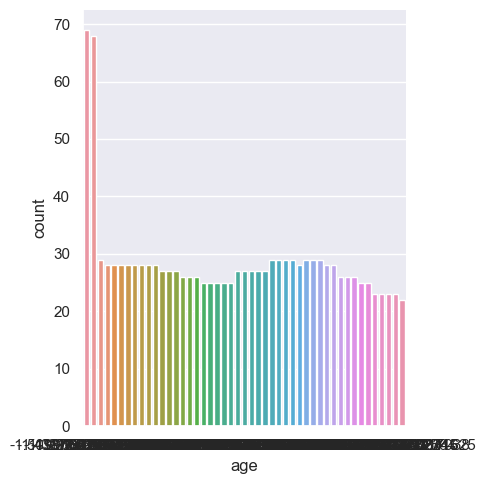

In [63]:
sb.factorplot('age',data=insurance_dataset,kind='count')

In [64]:
# model training

# linear regression

regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [65]:
LinearRegression(copy_X=True,fit_intercept= True,n_jobs=None,normalize=False)

LinearRegression(normalize=False)

In [66]:
training_data_prediction = regressor.predict(X_train)

In [67]:
r2_train = metrics.r2_score(y_train,training_data_prediction)
print('R squared value :',r2_train)

R squared value : 0.7445275825163911


In [68]:
test_data_prediction = regressor.predict(X_test)

In [69]:
r2_test= metrics.r2_score(y_test,test_data_prediction)
print('R squared value :',r2_test)

R squared value : 0.7667469908213234


## Building a predictive system

In [70]:
input_data = (31,1,25.74,0,1,0)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)
print(prediction)

[174289.10008086]


In [71]:
print('The insurance cost is USD',prediction[0])

The insurance cost is USD 174289.1000808612


In [72]:
if (prediction[0])==0:
    print('The person has no  insursnce')
else:
    print('The person has insurance')

The person has insurance


## saving the train model

In [73]:
import pickle

In [74]:
filename = 'trained_model.sav'
pickle.dump(regressor,open(filename,'wb'))

## loading the saved model

In [75]:
loaded_model = pickle.load(open('trained_model.sav','rb'))

In [76]:
input_data = (31,1,25.74,0,1,0)

input_data_as_numpy_array = np.asarray(input_data)

input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = regressor.predict(input_data_reshaped)
print(prediction)


if (prediction[0])==0:
    print('The person has no  insursnce')
else:
    print('The person has insurance')

[174289.10008086]
The person has insurance
